In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

sns.set_style("whitegrid")


In [3]:
df = pd.read_csv("C:/Users/VIKAS/Desktop/Disease_Prediction_Project/data/parkinsons.csv")
df.head()


,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


<class 'pandas.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    str    
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null    float64
 17  status  

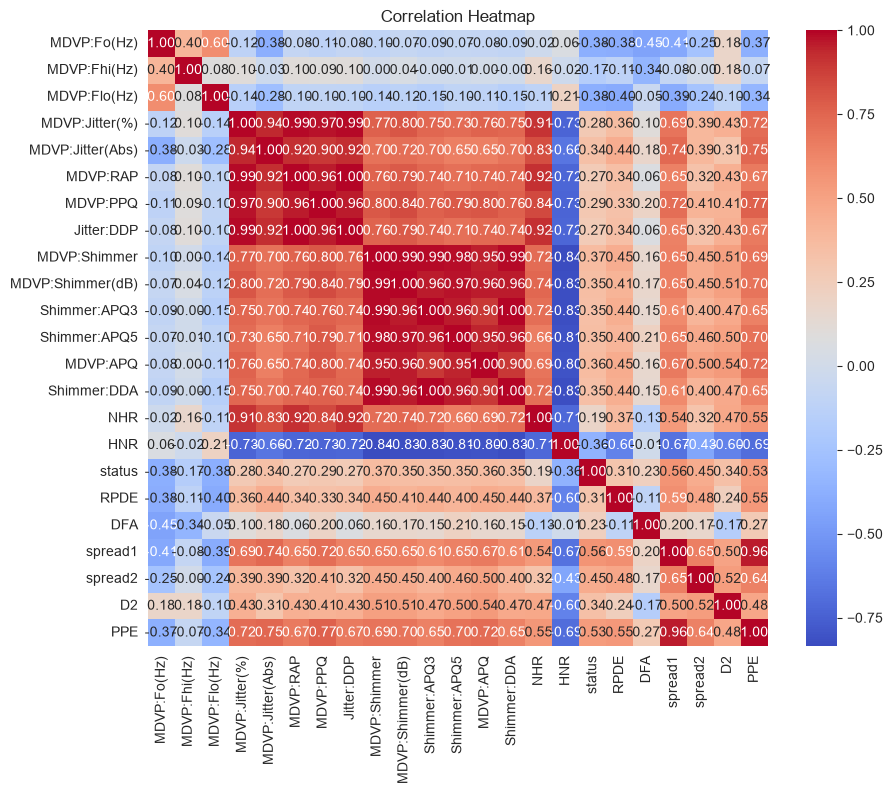

In [4]:
print(df.info())
print(df.describe())
print("\nMissing values:\n", df.isnull().sum())
print("\nClass balance:\n", df['status'].value_counts())

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [5]:
df = df.drop('name', axis=1)

X = df.drop('status', axis=1)
y = df['status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [6]:
models = {
    "svm": SVC(probability=True, random_state=42),
    "random_forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "xgboost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

trained_models = {}
results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({"model": name, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1})
    trained_models[name] = model

    print(f"\n--- {name} ---")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))

results_df = pd.DataFrame(results).sort_values(by="f1", ascending=False)
results_df


C:\Users\VIKAS\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



--- svm ---
[[ 7  3]
 [ 0 29]]
              precision    recall  f1-score   support

           0       1.00      0.70      0.82        10
           1       0.91      1.00      0.95        29

    accuracy                           0.92        39
   macro avg       0.95      0.85      0.89        39
weighted avg       0.93      0.92      0.92        39


--- random_forest ---
[[ 8  2]
 [ 1 28]]
              precision    recall  f1-score   support

           0       0.89      0.80      0.84        10
           1       0.93      0.97      0.95        29

    accuracy                           0.92        39
   macro avg       0.91      0.88      0.90        39
weighted avg       0.92      0.92      0.92        39



C:\Users\VIKAS\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:13:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- xgboost ---
[[ 8  2]
 [ 1 28]]
              precision    recall  f1-score   support

           0       0.89      0.80      0.84        10
           1       0.93      0.97      0.95        29

    accuracy                           0.92        39
   macro avg       0.91      0.88      0.90        39
weighted avg       0.92      0.92      0.92        39



,model,accuracy,precision,recall,f1
0,svm,0.923077,0.906250,1.000000,0.950820
1,random_forest,0.923077,0.933333,0.965517,0.949153
2,xgboost,0.923077,0.933333,0.965517,0.949153


In [7]:
os.makedirs('../models/parkinsons', exist_ok=True)

for name, model in trained_models.items():
    joblib.dump(model, f'../models/parkinsons/{name}.pkl')

joblib.dump(scaler, '../models/parkinsons/scaler.pkl')
results_df.to_json('../models/parkinsons/metrics.json', orient='records')

print("Saved all models, scaler, and metrics.")


Saved all models, scaler, and metrics.


In [8]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

shap.initjs()


In [9]:
disease = "parkinsons"
best_model_name = "random_forest"   # <-- replace with your actual best model from results_df above

model = joblib.load(f'../models/{disease}/{best_model_name}.pkl')
scaler = joblib.load(f'../models/{disease}/scaler.pkl')

df = pd.read_csv("C:/Users/VIKAS/Desktop/Disease_Prediction_Project/data/parkinsons.csv")
df = df.drop('name', axis=1)

X = df.drop('status', axis=1)
feature_names = X.columns.tolist()
X_scaled = scaler.transform(X)


In [10]:
# Tree-based models (RandomForest, XGBoost, DecisionTree) -> TreeExplainer (fast)
# Others (LogisticRegression, SVM, KNN, Naive Bayes) -> KernelExplainer (slower, needs background sample)

tree_models = ["random_forest", "xgboost", "decision_tree"]

if best_model_name in tree_models:
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_scaled)
    # For binary classifiers, shap_values may be a list [class0, class1] -> take class 1
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
else:
    background = shap.sample(X_scaled, 100, random_state=42)
    explainer = shap.KernelExplainer(model.predict_proba, background)
    shap_values = explainer.shap_values(X_scaled[:100])  # limit rows, KernelExplainer is slow


<Figure size 640x480 with 0 Axes>

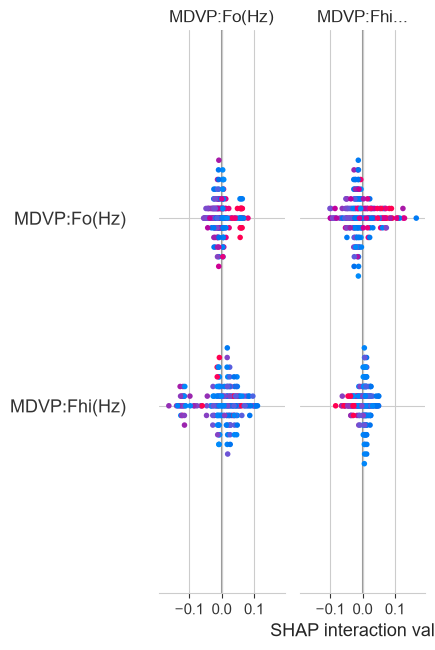

In [11]:
plt.figure()
shap.summary_plot(shap_values, X_scaled if best_model_name in tree_models else X_scaled[:100],
                   feature_names=feature_names, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig(f'../models/{disease}/shap_summary_bar.png', dpi=150)
plt.show()


<Figure size 640x480 with 0 Axes>

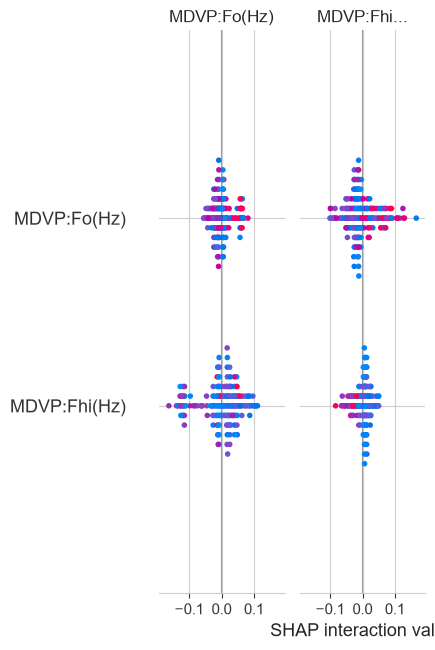

In [12]:
plt.figure()
shap.summary_plot(shap_values, X_scaled if best_model_name in tree_models else X_scaled[:100],
                   feature_names=feature_names, show=False)
plt.tight_layout()
plt.savefig(f'../models/{disease}/shap_summary_beeswarm.png', dpi=150)
plt.show()


In [13]:
def explain_single_prediction(patient_row_scaled, explainer, feature_names, is_tree_model):

    # Get SHAP values
    if is_tree_model:
        sv = explainer.shap_values(patient_row_scaled)

        # Binary classification case
        if isinstance(sv, list):
            sv = sv[1]

        sv = sv[0]  # take first sample

    else:
        sv = explainer.shap_values(patient_row_scaled)

        # Binary classification case
        if isinstance(sv, list):
            sv = sv[1]

        sv = sv[0]

    # Important fix
    sv = np.array(sv).reshape(-1)   # ensures 1D

    # Create dataframe
    impact_df = pd.DataFrame({
        "feature": feature_names,
        "shap_value": sv
    })

    impact_df["abs_impact"] = impact_df["shap_value"].abs()

    return impact_df.sort_values("abs_impact", ascending=False)
